In [6]:
import torch
# Force a call to the driver immediately
try:
    torch.cuda.init()
    print("Success!")
except Exception as e:
    print(f"Failed: {e}")

print(torch.cuda.is_available())

Success!
True


In [17]:
import os
import random
import shutil
import requests
import zipfile
import numpy as np
import soundfile as sf
from tqdm import tqdm
from pathlib import Path
from sklearn.model_selection import train_test_split

def download_and_prepare_speech_commands(
    output_dir="data",
    target_classes=("yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"),
    samples_per_class=3800, 
    seed=42,
    zip_output=True,
    clean=False
):
    url = "http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz"
    archive_path = "speech_commands_v0.02.tar.gz"
    extracted_path = "speech_commands"

    random.seed(seed)
    os.makedirs(output_dir, exist_ok=True)

    # Step 1: Download
    if not os.path.exists(archive_path):
        print("Downloading dataset...")
        response = requests.get(url, stream=True)
        total_size = int(response.headers.get('content-length', 0))
        with open(archive_path, 'wb') as f, tqdm(
            desc=archive_path, total=total_size,
            unit='iB', unit_scale=True, unit_divisor=1024,
        ) as bar:
            for data in response.iter_content(chunk_size=1024):
                bar.update(f.write(data))

    # Step 2: Extract 
    if not os.path.exists(extracted_path):
        print("Extracting dataset...")
        shutil.unpack_archive(archive_path, extracted_path)

    # Step 3: Choose unknown source classes
    all_dirs=[d for d in Path(extracted_path).iterdir() if d.is_dir()]
    all_classes = [d.name for d in all_dirs if not d.name.startswith('_')]
    
    unknown_source_classes=sorted(set(all_classes)-set(target_classes))
    print(f"\nTarget classes   : {list(target_classes)}")
    print(f"Unknown sources  : {unknown_source_classes}")

    # Step 4: Gather files
    class_to_files = {}
    for cls in target_classes:
        files = list((Path(extracted_path) / cls).glob("*.wav"))
        class_to_files[cls] = files

    # Sample evenly from each unknown source class
    unknown_files = []
    for cls in unknown_source_classes:
        unknown_files.extend(list((Path(extracted_path)/cls).glob("*.wav")))

    random.shuffle(unknown_files)
    class_to_files["unknown"] = unknown_files[:samples_per_class]

    # Step 5: Generate Silence Class
    print("\nGenerating 'silence' class from background noise...")
    silence_dir=Path(extracted_path)/"silence_generated"
    silence_dir.mkdir(exist_ok=True)
    bg_path=Path(extracted_path)/'_background_noise_'
    
    silence_files=[]
    if bg_path.exists():
        bg_files=list(bg_path.glob('*.wav'))
        all_bg_audio=[]
        for f in bg_files:
            y, sr=sf.read(f)
            if len(y.shape)>1: y=y[:,0]
            all_bg_audio.append(y)
            
        if all_bg_audio:
            long_noise=np.concatenate(all_bg_audio)
            samples_per_clip=16000
            for i in tqdm(range(samples_per_class), desc="Slicing Silence"):
                start_idx=random.randint(0, len(long_noise)-samples_per_clip)
                clip=long_noise[start_idx:start_idx+samples_per_clip]
                out_file=silence_dir/f"silence_{i:04d}.wav"
                sf.write(out_file, clip, 16000)
                silence_files.append(out_file)
    class_to_files["silence"]=silence_files
    
    # Step 6: Report balance before splitting 
    print(f"\nClass sizes before split:")
    for cls, files in class_to_files.items():
        print(f"  {cls:<10}: {len(files):5d} files")
    sizes=[len(f) for f in class_to_files.values()]
    ratio=max(sizes)/min(sizes)
    print(f"\nImbalance ratio: {ratio:.2f}")

    # Step 7: Train/val/test split (70/15/15)
    splits={}
    for cls, files in class_to_files.items():
        train, temp = train_test_split(files, test_size=0.30, random_state=seed)
        val, test   = train_test_split(temp,  test_size=0.50, random_state=seed)
        splits[cls] = {"train": train, "val": val, "test": test}

    # Step 8: Copy into output folder
    for cls, split_dict in splits.items():
        for split, files in split_dict.items():
            out_dir = Path(output_dir) / split / cls
            out_dir.mkdir(parents=True, exist_ok=True)
            for f in files:
                shutil.copy(f, out_dir / f.name)

    # Step 8: Zip
    if zip_output:
        zip_path = f"{output_dir}.zip"
        print(f"\nCreating zip at {zip_path}...")
        with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
            for root, _, files in os.walk(output_dir):
                for file in files:
                    fp = os.path.join(root, file)
                    zipf.write(fp, os.path.relpath(fp, output_dir))
        print(f"Saved: {zip_path}")

    # Step 9: Cleanup 
    if clean:
        print("Cleaning up intermediate files...")
        for path in [extracted_path, output_dir, archive_path]:
            if os.path.exists(path):
                shutil.rmtree(path) if os.path.isdir(path) else os.remove(path)
        print("Cleanup complete.")

    # Summary
    print("\nFinal split summary:")
    print(f"  {'Class':<12} {'Train':>7} {'Val':>7} {'Test':>7} {'Total':>7}")
    print(f"  {'-'*40}")
    for cls, split_dict in splits.items():
        tr = len(split_dict['train'])
        va = len(split_dict['val'])
        te = len(split_dict['test'])
        print(f"  {cls:<12} {tr:>7} {va:>7} {te:>7} {tr+va+te:>7}")

    return splits


# Usage 
if __name__ == "__main__":
    download_and_prepare_speech_commands(
        samples_per_class=3800,
        seed=42,
        zip_output=True,
        clean=True
    )

speech_commands_v0.02.tar.gz: 100%|██████████| 2.26G/2.26G [08:38<00:00, 4.68MiB/s] 


Extracting dataset...

Target classes   : ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']
Unknown sources  : ['backward', 'bed', 'bird', 'cat', 'dog', 'eight', 'five', 'follow', 'forward', 'four', 'happy', 'house', 'learn', 'marvin', 'nine', 'one', 'seven', 'sheila', 'six', 'three', 'tree', 'two', 'visual', 'wow', 'zero']

Generating 'silence' class from background noise...


Slicing Silence: 100%|██████████| 3800/3800 [00:03<00:00, 1042.98it/s]



Class sizes before split:
  yes       :  4044 files
  no        :  3941 files
  up        :  3723 files
  down      :  3917 files
  left      :  3801 files
  right     :  3778 files
  on        :  3845 files
  off       :  3745 files
  stop      :  3872 files
  go        :  3880 files
  unknown   :  3800 files
  silence   :  3800 files

Imbalance ratio: 1.09

Creating zip at data.zip...
Saved: data.zip
Cleaning up intermediate files...
Cleanup complete.

Final split summary:
  Class          Train     Val    Test   Total
  ----------------------------------------
  yes             2830     607     607    4044
  no              2758     591     592    3941
  up              2606     558     559    3723
  down            2741     588     588    3917
  left            2660     570     571    3801
  right           2644     567     567    3778
  on              2691     577     577    3845
  off             2621     562     562    3745
  stop            2710     581     581    3872
  go  

In [18]:
import zipfile
import io
import os
import numpy as np
import librosa
import soundfile as sf
import tempfile
from tqdm import tqdm
import warnings

# === Silence noisy warnings from librosa ===
warnings.filterwarnings("ignore", category=UserWarning, module="librosa")
warnings.filterwarnings("ignore", category=FutureWarning, module="librosa")

# === Constants (matching C implementation) ===
SAMPLE_RATE = 16000
FRAME_DUR = 0.032
FRAME_SIZE = int(SAMPLE_RATE * FRAME_DUR)  # 512
FRAME_STRIDE_DUR = 0.024
FRAME_STRIDE = int(SAMPLE_RATE * FRAME_STRIDE_DUR)  # 384
NUM_BINS = FRAME_SIZE // 2  # 256
FILTER_NUMBER = 40
MIN_FREQ = 0
MAX_FREQ = SAMPLE_RATE // 2  # 8000
COEFFICIENT = 0.96875
NOISE_FLOOR = -40.0
SEGMENT_SEC = 1.0

# === C-style implementation functions ===
def pre_emphasis(audio):
    """Pre-emphasis matching C implementation"""
    emphasized = np.zeros_like(audio, dtype=np.float32)
    audio_scaled=audio/32768.0
    emphasized[0] = audio_scaled[0]
    emphasized[1:]=audio_scaled[1:]-COEFFICIENT*audio_scaled[:-1]
    return emphasized

def apply_windowing(frame):
    """Hamming window matching C implementation"""
    window = 0.54 - 0.46 * np.cos(2 * np.pi * np.arange(len(frame)) / (len(frame) - 1))
    return frame * window

def hz_to_mel(hz):
    """Hz to Mel conversion matching C implementation"""
    return 1127.0 * np.log10(1 + hz / 700.0)

def mel_to_hz(mel):
    """Mel to Hz conversion matching C implementation"""
    return 700 * (10 ** (mel / 1127.0) - 1)

def create_mel_filterbank():
    """Create mel filterbank matching C implementation"""
    min_mel = hz_to_mel(MIN_FREQ)
    max_mel = hz_to_mel(MAX_FREQ)
    
    mel_points = np.zeros(FILTER_NUMBER + 2)
    mel_spacing = (max_mel - min_mel) / (FILTER_NUMBER + 1)
    for i in range(FILTER_NUMBER + 2):
        mel_points[i] = mel_to_hz(min_mel + i * mel_spacing)
        if mel_points[i] > MAX_FREQ:
            mel_points[i] = MAX_FREQ

    bin_indices = np.zeros(FILTER_NUMBER + 2, dtype=int)
    for i in range(FILTER_NUMBER + 2):
        bin_indices[i] = int(mel_points[i] * (NUM_BINS - 1) / (SAMPLE_RATE / 2.0))
        bin_indices[i] = max(0, min(NUM_BINS - 1, bin_indices[i]))

    filterbank = np.zeros((FILTER_NUMBER, NUM_BINS))

    for i in range(FILTER_NUMBER):
        left = bin_indices[i]
        middle = bin_indices[i+1]
        right = bin_indices[i+2]

        if left == middle:
            middle = min(left + 1, NUM_BINS - 1)
        if middle == right:
            right = min(middle + 1, NUM_BINS - 1)

        # Rising slope
        for j in range(left, middle):
            filterbank[i, j] = (j - left) / (middle - left)

        # Falling slope
        for j in range(middle, right):
            filterbank[i, j] = 1.0 - (j - middle) / (right - middle)
    
    return filterbank

def compute_spectrogram_c_style(audio_int16, target_frames=None):
    """
    Compute spectrogram using C-style implementation
    audio_int16: int16 audio samples
    target_frames: if specified, pad/truncate to this many frames
    """
    num_samples = len(audio_int16)
    total_duration = num_samples / SAMPLE_RATE
    num_frames_available = int((total_duration - FRAME_DUR) / FRAME_STRIDE_DUR) + 1
    if target_frames:
        num_frames = min(num_frames_available, target_frames)
    else:
        num_frames = min(num_frames_available, 42)  # ~1 second max
    # Pre-emphasis
    pre_emphasis_array = pre_emphasis(audio_int16)
    # Initialize spectrogram
    spectrogram = np.zeros((num_frames, NUM_BINS))
    # Frame processing
    for frame in range(num_frames):
        start = frame * FRAME_STRIDE
        end = start + FRAME_SIZE
        segment = pre_emphasis_array[start:end]
        if len(segment) < FRAME_SIZE:
            segment = np.pad(segment, (0, FRAME_SIZE - len(segment)))
        # Apply windowing
        windowed = apply_windowing(segment)
        # FFT
        fft = np.fft.rfft(windowed, n=FRAME_SIZE)
        spectrogram[frame]=np.abs(fft)[:NUM_BINS]
        #magnitude = np.abs(fft)
        #spectrogram[frame] = magnitude[:NUM_BINS]

    # Apply mel filterbank
    mel_filterbank = create_mel_filterbank()
    mel_spectrogram = np.dot(spectrogram, mel_filterbank.T)
    # Convert to log scale
    log_mel_spectrogram = 10 * np.log10(mel_spectrogram + 1e-20)
    # Apply noise floor and normalization (matching C implementation)
    log_mel_spectrogram = (log_mel_spectrogram - NOISE_FLOOR) / (-NOISE_FLOOR + 12)
    log_mel_spectrogram = np.clip(log_mel_spectrogram, 0, 1)
    # Quantization
    quantized = np.round(log_mel_spectrogram * 256) / 256.0
    # Hard threshold
    #quantized = np.where(quantized >= 0.65, quantized, 0)
    if target_frames:
        if quantized.shape[0] < target_frames:
            quantized = np.pad(quantized, ((0, target_frames - quantized.shape[0]), (0, 0)))
        else:
            quantized = quantized[:target_frames]

    return quantized

# === Robust loader ===
def load_audio_from_zip(z, fname, target_sr=16000):
    try:
        with z.open(fname) as file_data:
            wav_bytes = io.BytesIO(file_data.read())

            try:
                # First try with soundfile
                y, sr = sf.read(wav_bytes, dtype="float32")
            except Exception:
                # Fallback: audioread (via temp file)
                with tempfile.NamedTemporaryFile(suffix=".wav") as tmp:
                    tmp.write(wav_bytes.getbuffer())
                    tmp.flush()
                    y, sr = librosa.load(tmp.name, sr=None)

            # Resample if needed
            if sr != target_sr:
                y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
                sr = target_sr

            return np.asarray(y, dtype=np.float32), sr

    except Exception as e:
        print(f"[WARN] Skipping {fname} due to error: {e}")
        return None, None

# === MFE Extraction using C-style implementation ===
def extract_mfe_segments_c_style(y, sr, segment_sec=SEGMENT_SEC, target_frames=None):
    """Extract MFE segments using C-style implementation"""
    #max_val = np.max(np.abs(y))
    #if max_val == 0 or not np.isfinite(max_val):
    #    return []
    
    # Normalize to [-1, 1] range
    #y = y / max_val
    if not np.all(np.isfinite(y)):
        return []
    
    # Convert to int16 format (as expected by C-style implementation)
    y_int16 = np.clip(y * 32767, -32768, 32767).astype(np.int16)
    
    mfe_segments = []
    segment_samples = int(segment_sec * sr)
    
    for start_idx in range(0, len(y_int16), segment_samples):
        end_idx = start_idx + segment_samples
        if end_idx > len(y_int16):
            # For the last segment, take what's available
            segment = y_int16[start_idx:]
            if len(segment) < segment_samples // 2:  # Skip very short segments
                break
        else:
            segment = y_int16[start_idx:end_idx]

        # Compute spectrogram using C-style implementation
        mfe = compute_spectrogram_c_style(segment, target_frames=target_frames)
        mfe_segments.append(mfe)

    return mfe_segments

# === Main processing from ZIP ===
def process_zip_dataset(zip_path, output_path, segment_sec=1.0, target_frames=None, clean=False):
    samples = []
    labels = []
    label_map = {}
    skipped = 0

    with zipfile.ZipFile(zip_path, "r") as z:
        wav_files = [
            f for f in z.namelist() 
            if f.lower().endswith(".wav") and "__macosx" not in f.lower()
        ]

        for f in tqdm(wav_files, desc="Processing WAVs"):
            # Label = parent folder name
            parts = f.split("/")
            if len(parts) >= 2:
                label = parts[-2]
            else:
                label = "unknown"

            if label not in label_map:
                label_map[label] = len(label_map)

            # Load audio
            y, sr = load_audio_from_zip(z, f, target_sr=SAMPLE_RATE)
            if y is None:
                skipped += 1
                continue

            # Extract features using C-style implementation
            mfe_segments = extract_mfe_segments_c_style(y, sr, segment_sec=segment_sec, target_frames=target_frames)

            for mfe in mfe_segments:
                samples.append(mfe)
                labels.append(label_map[label])

    # Convert to numpy arrays
    samples = np.array(samples, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)

    # Save
    np.savez_compressed(
        output_path,
        features=samples,
        labels=labels,
        label_map=label_map
    )

    if clean:
        print("Cleaning up intermediate files to free memory...")
        if os.path.exists(zip_path):
            os.remove(zip_path)
        print("Cleanup complete. Only final zip kept.")
    
    print("\n" + "="*50)
    print("PROCESSING DETAILED SUMMARY")
    print("="*50)
    print(f"Total WAV files found    : {len(wav_files)}")
    print(f"Total files processed    : {len(wav_files) - skipped}")
    print(f"Total files skipped      : {skipped}")
    print(f"Total valid segments     : {len(samples)}")
    print(f"Classes found            : {len(label_map)}")
    print(f"Label map                : {label_map}")
    print(f"Feature shape            : {samples.shape if len(samples) > 0 else 'N/A'}")
    print(f"\nSaved dataset: {output_path}")
    print("="*50)

# === Run ===
if __name__ == "__main__":
    process_zip_dataset(
        zip_path="data.zip",
        output_path="dataset_kws_multi.npz",
        segment_sec=1.0,
        target_frames=40,  
        clean=True
    )

Processing WAVs: 100%|██████████| 45569/45569 [01:36<00:00, 473.21it/s]


Cleaning up intermediate files to free memory...
Cleanup complete. Only final zip kept.

PROCESSING DETAILED SUMMARY
Total WAV files found    : 45569
Total files processed    : 45569
Total files skipped      : 0
Total valid segments     : 45487
Classes found            : 12
Label map                : {'right': 0, 'off': 1, 'down': 2, 'yes': 3, 'no': 4, 'unknown': 5, 'stop': 6, 'left': 7, 'go': 8, 'up': 9, 'on': 10, 'silence': 11}
Feature shape            : (45487, 40, 40)

Saved dataset: dataset_kws_multi.npz


Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
LOADING DATASET
Train: (31840, 40, 40), Val: (6823, 40, 40), Test: (6824, 40, 40)
Number of classes: 12
Added channel dimension: (31840, 40, 40, 1)
Class names: ['right', 'off', 'down', 'yes', 'no', 'unknown', 'stop', 'left', 'go', 'up', 'on', 'silence']
NUM CLASSES: 12

PyTorch tensor shapes:
X_train: torch.Size([31840, 1, 40, 40]), y_train: torch.Size([31840])
X_val: torch.Size([6823, 1, 40, 40]), y_val: torch.Size([6823])
X_test: torch.Size([6824, 1, 40, 40]), y_test: torch.Size([6824])

CREATING MODEL
TeacherCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.2, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2)

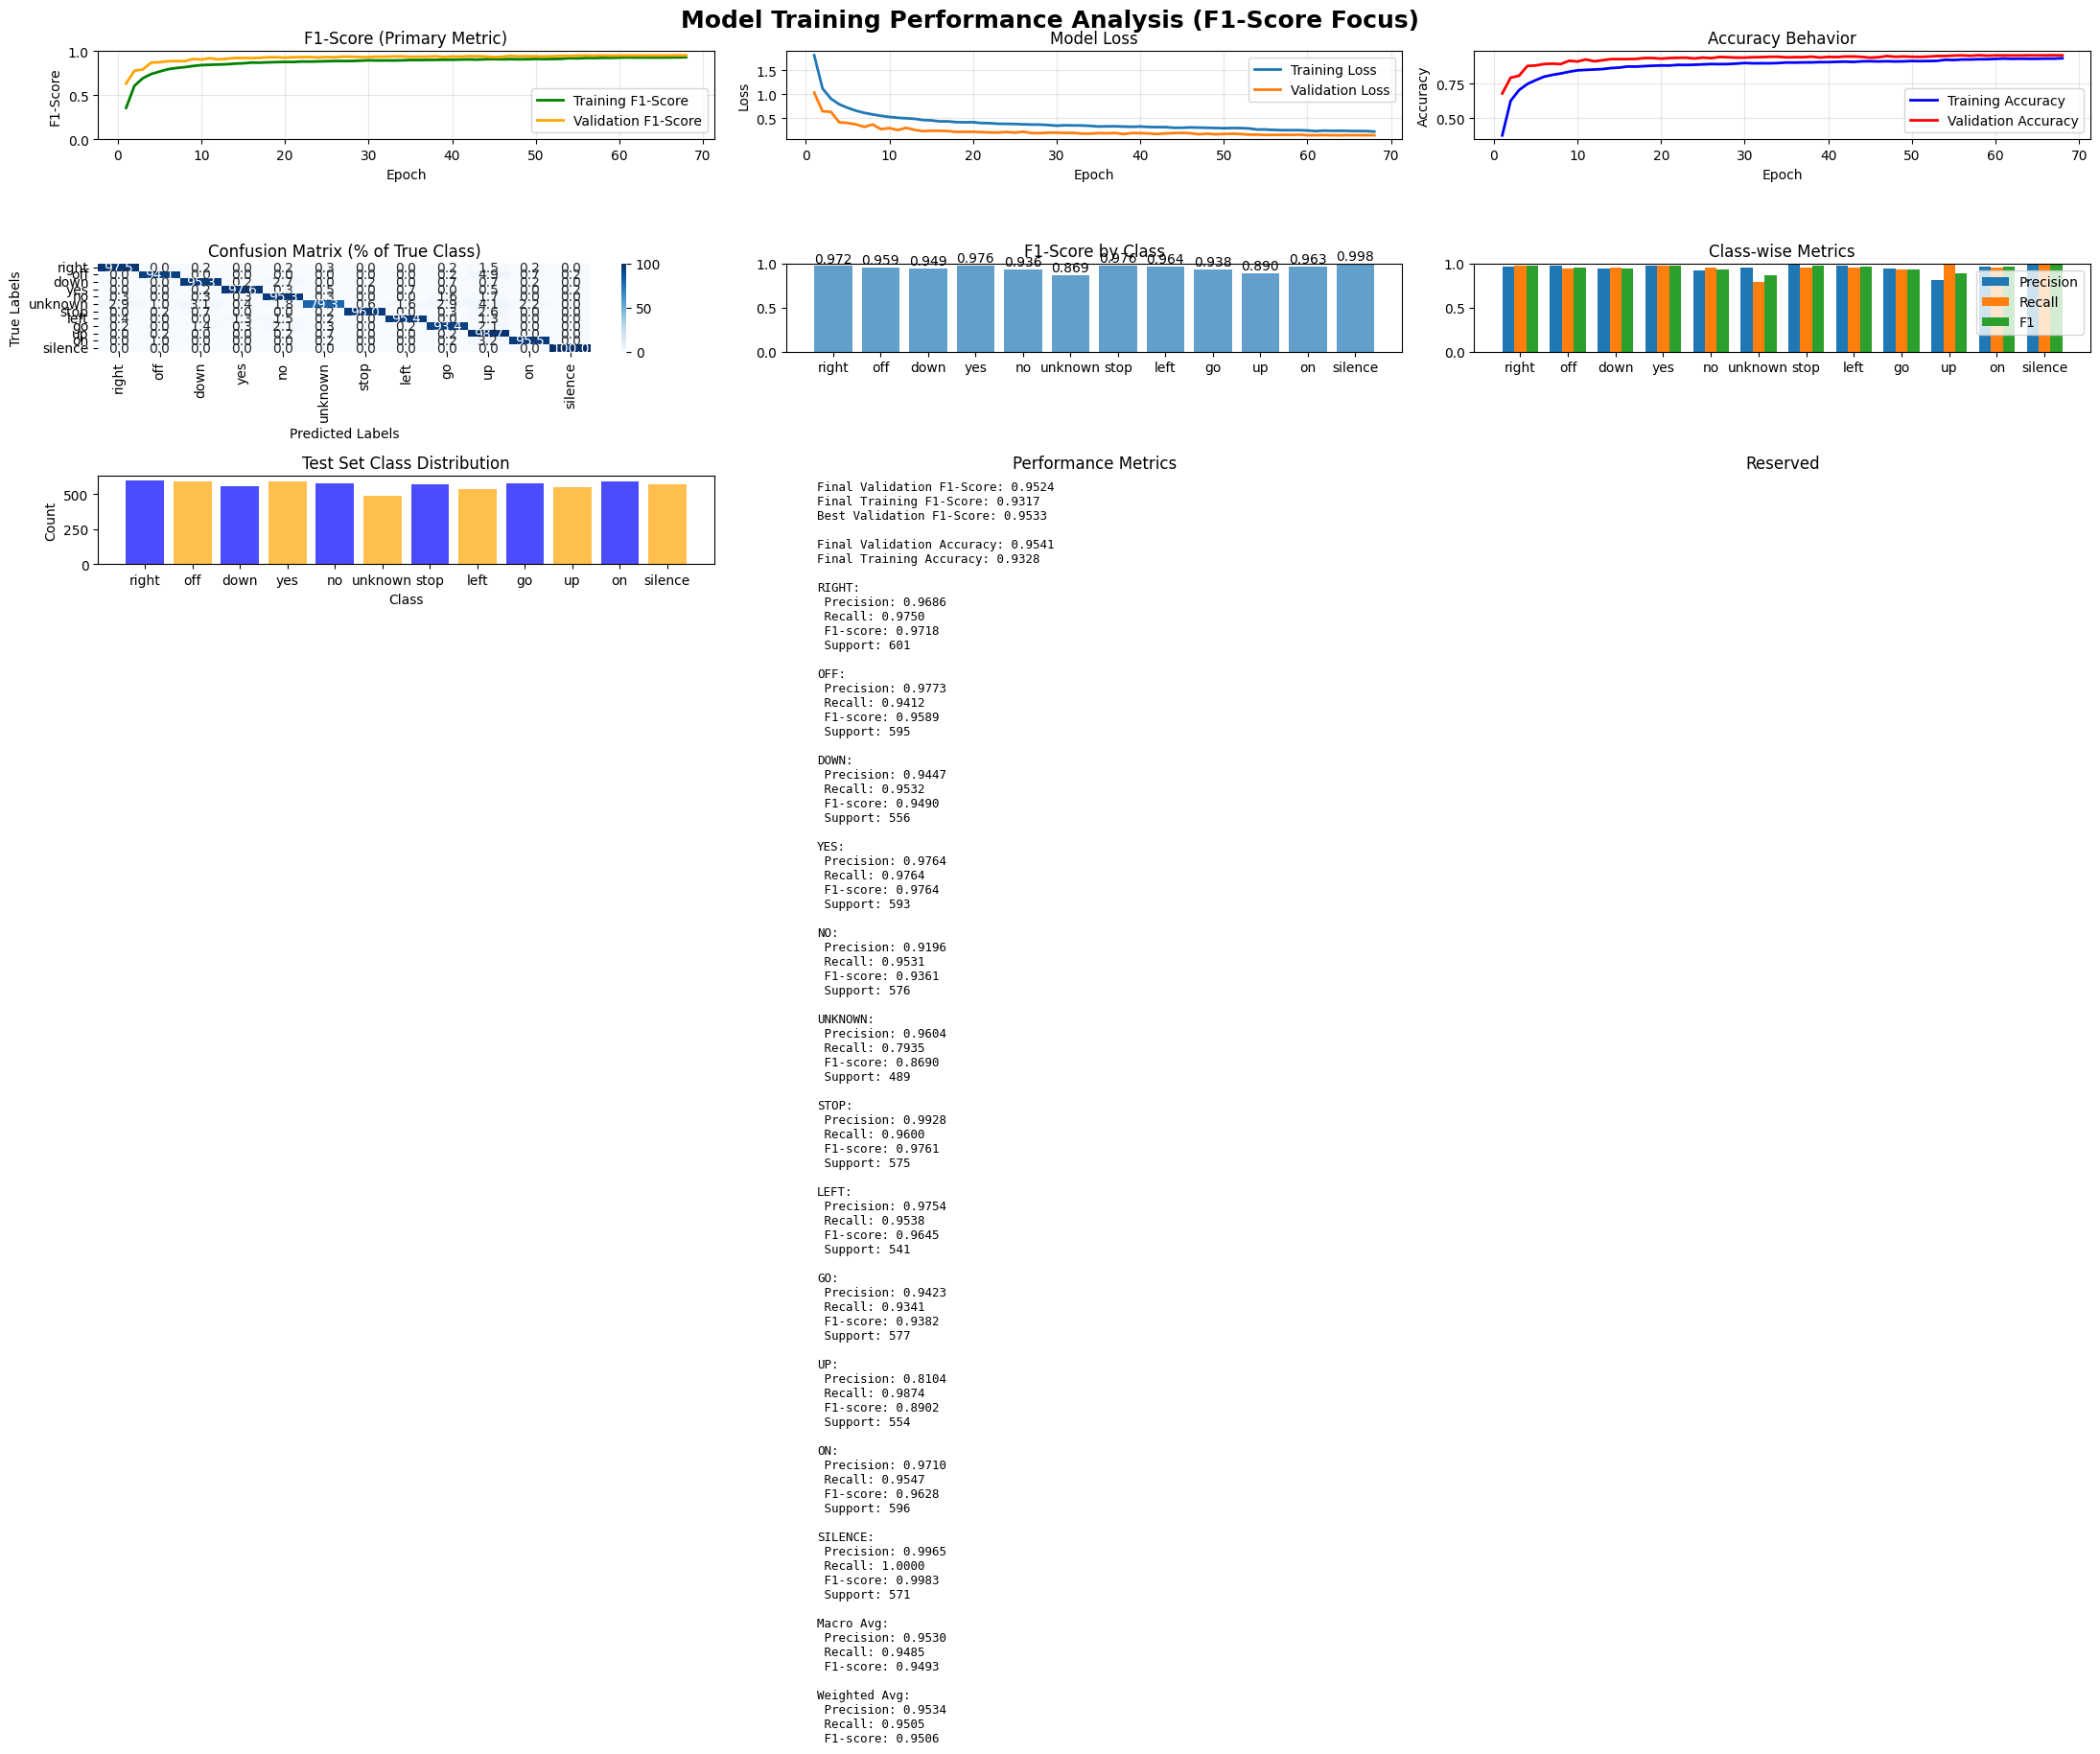

TRAINING SUMMARY (F1-Score Focus)
Total epochs trained: 68
Final training F1-score: 0.9317
Final validation F1-score: 0.9524
Best validation F1-score: 0.9533
Final training accuracy: 0.9328
Final validation accuracy: 0.9541
Final training loss: 0.2239
Final validation loss: 0.1467

Test Set Performance:
              precision    recall  f1-score   support

       right       0.97      0.98      0.97       601
         off       0.98      0.94      0.96       595
        down       0.94      0.95      0.95       556
         yes       0.98      0.98      0.98       593
          no       0.92      0.95      0.94       576
     unknown       0.96      0.79      0.87       489
        stop       0.99      0.96      0.98       575
        left       0.98      0.95      0.96       541
          go       0.94      0.93      0.94       577
          up       0.81      0.99      0.89       554
          on       0.97      0.95      0.96       596
     silence       1.00      1.00      1.00   

In [22]:
import os
import gc
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, f1_score, precision_recall_fscore_support)
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


def create_dataset(shape_input, file, values_name, labels_name, threshold, percentage=1.0):
    """Load and prepare dataset from .npz file"""
    if len(shape_input) == 3:
        height, width, channels = shape_input
    elif len(shape_input) == 2:
        height, width = shape_input
        channels = 1
    else:
        raise ValueError("Shape Input must be (height, width) or (height, width, channels)")

    # Load dataset
    dataset = np.load(file)
    samples = dataset[values_name][:, :height, :width]
    classes = dataset[labels_name].astype(int)

    # Filter / balance classes
    filtered_samples, filtered_classes = [], []
    unique_classes, counts = np.unique(classes, return_counts=True)
    keep_classes = unique_classes if threshold == -1 else unique_classes[counts >= threshold]

    for cls in keep_classes:
        cls_indices = np.where(classes == cls)[0]
        if threshold != -1:
            cls_indices = np.random.choice(cls_indices, size=threshold, replace=False)
        filtered_samples.append(samples[cls_indices])
        filtered_classes.append(classes[cls_indices])

    filtered_samples = np.concatenate(filtered_samples)
    filtered_classes = np.concatenate(filtered_classes)

    # Normalize class indices
    unique_classes = np.unique(filtered_classes)
    class_mapping = {cls: idx for idx, cls in enumerate(unique_classes)}
    filtered_classes = np.array([class_mapping[cls] for cls in filtered_classes])

    # Split into train/val/test
    X_train, X_temp, y_train, y_temp = train_test_split(
        filtered_samples, filtered_classes, test_size=0.3, random_state=seed)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=seed)

    # Dataset reduction for training set
    if percentage < 1.0:
        X_train_reduced, y_train_reduced = [], []
        for cls in np.unique(y_train):
            cls_indices = np.where(y_train == cls)[0]
            n_keep = int(len(cls_indices) * percentage)
            selected = np.random.choice(cls_indices, size=n_keep, replace=False)
            X_train_reduced.append(X_train[selected])
            y_train_reduced.append(y_train[selected])
        X_train = np.concatenate(X_train_reduced)
        y_train = np.concatenate(y_train_reduced)

    # Expand dims if grayscale input
    if len(shape_input) == 2:
        X_train = np.expand_dims(X_train, axis=-1)
        X_val = np.expand_dims(X_val, axis=-1)
        X_test = np.expand_dims(X_test, axis=-1)

    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    print(f"Number of classes: {len(unique_classes)}")
    
    if X_train.ndim==3:
        X_train=np.expand_dims(X_train, axis=-1)
        X_val=np.expand_dims(X_val, axis=-1)
        X_test=np.expand_dims(X_test, axis=-1)
        print(f"Added channel dimension: {X_train.shape}")
    return X_train, y_train, X_val, y_val, X_test, y_test, len(np.unique(classes))


class TeacherCNN(nn.Module):
    """CNN for keyword spotting with BatchNorm (PyTorch version)"""
    def __init__(self, input_shape, num_classes):
        super(TeacherCNN, self).__init__()
        
        # Conv block 1
        self.conv1 = nn.Conv2d(input_shape[2], 32, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.2)
        
        # Conv block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.3)
        
        # Conv block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop3 = nn.Dropout(0.4)
        
        # Calculate flattened size
        self.flat_size = 128 * 5 * 5
        
        # Dense layers
        self.fc1 = nn.Linear(self.flat_size, 256, bias=False)
        self.bn4 = nn.BatchNorm1d(256)
        self.relu4 = nn.ReLU()
        self.drop4 = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(256, 128, bias=False)
        self.bn5 = nn.BatchNorm1d(128)
        self.relu5 = nn.ReLU()
        self.drop5 = nn.Dropout(0.5)
        
        self.fc3 = nn.Linear(128, 64, bias=False)
        self.bn6 = nn.BatchNorm1d(64)
        self.relu6 = nn.ReLU()
        self.drop6 = nn.Dropout(0.5)
        
        self.fc_out = nn.Linear(64, num_classes)
        
    def forward(self, x):
        # Conv blocks
        x = self.drop1(self.pool1(self.relu1(self.bn1(self.conv1(x)))))
        x = self.drop2(self.pool2(self.relu2(self.bn2(self.conv2(x)))))
        x = self.drop3(self.pool3(self.relu3(self.bn3(self.conv3(x)))))
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Dense layers
        x = self.drop4(self.relu4(self.bn4(self.fc1(x))))
        x = self.drop5(self.relu5(self.bn5(self.fc2(x))))
        x = self.drop6(self.relu6(self.bn6(self.fc3(x))))
        x = self.fc_out(x)
        
        return x


class StudentDense(nn.Module):
    """Simple 3-layer dense network (PyTorch version)"""
    def __init__(self, input_size, num_classes):
        super(StudentDense, self).__init__()
        
        self.fc1 = nn.Linear(input_size, 256)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(256, 256)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.3)
        
        self.fc3 = nn.Linear(256, 256)
        self.relu3 = nn.ReLU()
        self.drop3 = nn.Dropout(0.3)
        
        self.fc_out = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = self.drop1(self.relu1(self.fc1(x)))
        x = self.drop2(self.relu2(self.fc2(x)))
        x = self.drop3(self.relu3(self.fc3(x)))
        x = self.fc_out(x)
        return x

class KnownOnlyCrossEntropy(nn.Module):
    def __init__(self, unknown_id: int, weight=None, label_smoothing: float=0.05):
        super().__init__()
        self.unknown_id=unknown_id
        self.ce=nn.CrossEntropyLoss(weight=weight, label_smoothing=label_smoothing)
        
    def forward(self, logits, labels):
        known_mask=(labels!=self.unknown_id)
        if not known_mask.any():
            return torch.tensor(0.0, device=logits.device, requires_grad=True)
        return self.ce(logits[known_mask], labels[known_mask])
    
def tune_threshold(model, val_loader, unknown_id, device, known_indices, verbose=True):
    model.eval()
    all_max_probs, all_labels=[], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs=inputs.to(device)
            logits=model(inputs)
            known_logits=logits[:,known_indices]
            known_probs=torch.softmax(known_logits, dim=1)
            max_prob=known_probs.max(dim=1).values
            all_max_probs.extend(max_prob.cpu().numpy())
            all_labels.extend(labels.numpy())
    probs=np.array(all_max_probs)
    labels=np.array(all_labels)
    unk_m=(labels==unknown_id)
    kno_m=~unk_m
    if verbose:
        print("\n"+"="*60)
        print("THRESHOLD CALIBRATION ON VALIDATION SET")
        print("="*60)
        print(f"    Val samples - known: {kno_m.sum():,} unknown: {unk_m.sum():,}")
        print(f"\n  {'T':>6} | {'Unk Recall':>10} | {'Known Acc':>10} | {'Harmonic':>10}")
    best_T, best_H=0.5, 0.0
    for T in np.arange(0.20, 0.92, 0.04):
        pred_unk=probs<T
        unk_recall=pred_unk[unk_m].mean() if unk_m.any() else 0.0
        known_acc=(~pred_unk[kno_m]).mean() if kno_m.any() else 0.0
        harmonic=2*unk_recall*known_acc/(unk_recall+known_acc+1e-8)
        mark="<" if harmonic>best_H else ""
        if verbose:
            print(f"  T={T:.2f} | {unk_recall*100:>9.1f}% | {known_acc*100:>9.1f}% | {harmonic:>10.4}{mark}")
        if harmonic>best_H:
            best_H, best_T=harmonic, float(T)
    if verbose:
        print(f"\n  Optimal threshold: {best_T:.2f} (harmonic={best_H:.4f})")
        print("="*60)
    return best_T
        
def evaluate_with_threshold(model, test_loader, class_names, unknown_id, device, known_indices, threshold):
    model.eval()
    all_preds, all_labels=[], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs=inputs.to(device)
            logits=model(inputs)
            known_logits=logits[:,known_indices]
            known_probs=torch.softmax(known_logits, dim=1)
            max_prob, best_known=known_probs.max(dim=1)
            known_id_t=torch.tensor(known_indices, device=device, dtype=torch.long)
            pred_known=known_id_t[best_known]
            final=torch.where(max_prob>=threshold, pred_known, torch.full_like(pred_known, unknown_id))
            all_preds.extend(final.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    preds=np.array(all_preds)
    labels=np.array(all_labels)
    overall_acc=(preds==labels).mean()
    print("\n"+"="*60)
    print(f"TEST EVALUATION (threshold={threshold:.2f})")
    print("="*60)
    print(f"Overall Accuracy: {overall_acc*100:.2f}%\n")
    for i, name in enumerate(class_names):
        mask=(labels==i)
        if mask.sum()>0:
            acc=(preds[mask]==labels[mask]).mean()
            tag=" <- unknown detector" if i==unknown_id else ""
            print(f"  {name:<10}: {acc*100:5.2f}% ({mask.sum()} samples){tag}")
    print("\n")
    print(classification_report(labels, preds, target_names=class_names, zero_division=0))
    cm=confusion_matrix(labels, preds)
    print("Confusion Matrix:")
    print(f"{'':>10}" + "".join(f"{n:>10}" for n in class_names))
    for i, name in enumerate(class_names):
        print(f"{name:>10}" + "".join(f"{cm[i,j]:>10}" for j in range(len(class_names))))
    return preds, labels    

def calculate_precision_recall_f1(y_true, y_pred, class_names):
    """Calculate precision, recall, and F1 for each class"""
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )
    
    results = {}
    for i, class_name in enumerate(class_names):
        results[class_name] = {
            'precision': precision[i],
            'recall': recall[i],
            'f1': f1[i],
            'support': support[i]
        }
    
    return results


def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    return running_loss/len(train_loader), correct/total, epoch_f1


def validate_epoch(model, val_loader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    correct=0
    total=0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total+=labels.size(0)
            correct+=predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_f1 = f1_score(
        all_labels, 
        all_preds, 
        average='macro',
        zero_division=0
    )
    
    return running_loss/len(val_loader), correct/total, epoch_f1


def plot_training_performance(history, model, test_loader, class_names, device):
    """Create comprehensive graphs showing training performance"""
    
    # Get predictions on test set
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    
    # Calculate precision, recall, F1 for each class
    metrics = calculate_precision_recall_f1(y_true, y_pred, class_names)
    
    # Create figure
    fig, axes = plt.subplots(3, 3, figsize=(22, 16))
    fig.suptitle('Model Training Performance Analysis (F1-Score Focus)', fontsize=18, fontweight='bold')
    
    # 1. F1-Score plot
    epochs = range(1, len(history['train_f1']) + 1)
    axes[0, 0].plot(epochs, history['train_f1'], label='Training F1-Score', linewidth=2, color='green')
    axes[0, 0].plot(epochs, history['val_f1'], label='Validation F1-Score', linewidth=2, color='orange')
    axes[0, 0].set_title('F1-Score (Primary Metric)')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('F1-Score')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_ylim(0, 1)
    
    # 2. Loss plot
    axes[0, 1].plot(epochs, history['train_loss'], label='Training Loss', linewidth=2)
    axes[0, 1].plot(epochs, history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Accuracy plot
    axes[0, 2].plot(epochs, history['train_acc'], label='Training Accuracy', linewidth=2, color='blue')
    axes[0, 2].plot(epochs, history['val_acc'], label='Validation Accuracy', linewidth=2, color='red')
    axes[0, 2].set_title('Accuracy Behavior')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Accuracy')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1, 0])
    axes[1, 0].set_title('Confusion Matrix (% of True Class)')
    axes[1, 0].set_xlabel('Predicted Labels')
    axes[1, 0].set_ylabel('True Labels')
    
    # 5. F1-Score by class
    class_f1_scores = [metrics[c]['f1'] for c in class_names]
    bars = axes[1, 1].bar(range(len(class_names)), class_f1_scores, alpha=0.7)
    axes[1, 1].set_title('F1-Score by Class')
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].set_xticks(range(len(class_names)))
    axes[1, 1].set_xticklabels(class_names)
    for bar, value in zip(bars, class_f1_scores):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{value:.3f}', ha='center', va='bottom')
    
    # 6. Precision-Recall-F1 grouped bars
    precision_values = [metrics[c]['precision'] for c in class_names]
    recall_values = [metrics[c]['recall'] for c in class_names]
    f1_values = [metrics[c]['f1'] for c in class_names]
    width = 0.25
    idx = np.arange(len(class_names))
    axes[1, 2].bar(idx - width, precision_values, width, label="Precision")
    axes[1, 2].bar(idx, recall_values, width, label="Recall")
    axes[1, 2].bar(idx + width, f1_values, width, label="F1")
    axes[1, 2].set_title('Class-wise Metrics')
    axes[1, 2].set_xticks(idx)
    axes[1, 2].set_xticklabels(class_names)
    axes[1, 2].legend()
    axes[1, 2].set_ylim(0, 1)
    
    # 7. Sample counts
    unique, counts = np.unique(y_true, return_counts=True)
    axes[2, 0].bar(unique, counts, color=['blue', 'orange'], alpha=0.7)
    axes[2, 0].set_title('Test Set Class Distribution')
    axes[2, 0].set_xlabel('Class')
    axes[2, 0].set_ylabel('Count')
    axes[2, 0].set_xticks(unique)
    axes[2, 0].set_xticklabels(class_names)
    
    # 8. Text metrics summary
    metrics_text = ""
    metrics_text += f"Final Validation F1-Score: {history['val_f1'][-1]:.4f}\n"
    metrics_text += f"Final Training F1-Score: {history['train_f1'][-1]:.4f}\n"
    metrics_text += f"Best Validation F1-Score: {max(history['val_f1']):.4f}\n\n"
    metrics_text += f"Final Validation Accuracy: {history['val_acc'][-1]:.4f}\n"
    metrics_text += f"Final Training Accuracy: {history['train_acc'][-1]:.4f}\n\n"
    
    for c in class_names:
        metrics_text += f"{c.upper()}:\n"
        metrics_text += f" Precision: {metrics[c]['precision']:.4f}\n"
        metrics_text += f" Recall: {metrics[c]['recall']:.4f}\n"
        metrics_text += f" F1-score: {metrics[c]['f1']:.4f}\n"
        metrics_text += f" Support: {metrics[c]['support']}\n\n"
    
    # Macro/weighted
    macro_precision = np.mean([metrics[c]['precision'] for c in class_names])
    macro_recall = np.mean([metrics[c]['recall'] for c in class_names])
    macro_f1 = np.mean([metrics[c]['f1'] for c in class_names])
    total_support = sum([metrics[c]['support'] for c in class_names])
    weighted_precision = sum([metrics[c]['precision'] * metrics[c]['support'] for c in class_names]) / total_support
    weighted_recall = sum([metrics[c]['recall'] * metrics[c]['support'] for c in class_names]) / total_support
    weighted_f1 = sum([metrics[c]['f1'] * metrics[c]['support'] for c in class_names]) / total_support
    
    metrics_text += f"Macro Avg:\n Precision: {macro_precision:.4f}\n Recall: {macro_recall:.4f}\n F1-score: {macro_f1:.4f}\n\n"
    metrics_text += f"Weighted Avg:\n Precision: {weighted_precision:.4f}\n Recall: {weighted_recall:.4f}\n F1-score: {weighted_f1:.4f}"
    
    axes[2, 1].text(0.05, 0.95, metrics_text, transform=axes[2, 1].transAxes,
                    fontfamily='monospace', verticalalignment='top', fontsize=9)
    axes[2, 1].set_title('Performance Metrics')
    axes[2, 1].set_axis_off()
    
    # 9. Reserved slot
    axes[2, 2].axis("off")
    axes[2, 2].set_title("Reserved")
    
    plt.tight_layout()
    plt.savefig('training_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print training summary
    print("=" * 60)
    print("TRAINING SUMMARY (F1-Score Focus)")
    print("=" * 60)
    print(f"Total epochs trained: {len(history['train_loss'])}")
    print(f"Final training F1-score: {history['train_f1'][-1]:.4f}")
    print(f"Final validation F1-score: {history['val_f1'][-1]:.4f}")
    print(f"Best validation F1-score: {max(history['val_f1']):.4f}")
    print(f"Final training accuracy: {history['train_acc'][-1]:.4f}")
    print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")
    print(f"Final training loss: {history['train_loss'][-1]:.4f}")
    print(f"Final validation loss: {history['val_loss'][-1]:.4f}")
    
    print("\nTest Set Performance:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    overall_f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"\nOverall Weighted F1-Score on Test Set: {overall_f1:.4f}")
    
    return fig


def main():
    # Load dataset
    print("="*60)
    print("LOADING DATASET")
    print("="*60)
    
    shape_input = (40, 40, 1)
    X_train, y_train, X_val, y_val, X_test, y_test, n_classes = create_dataset(
        shape_input, file="dataset_kws_multi.npz",
        values_name="features", labels_name="labels", threshold=-1, percentage=1.00)
    
    dataset_archive=np.load("dataset_kws_multi.npz", allow_pickle=True)
    label_map_dict=dataset_archive['label_map'].item()
    class_names=[k for k, v in sorted(label_map_dict.items(), key=lambda item: item[1])]
    print(f"Class names: {class_names}")
    print(f"NUM CLASSES: {n_classes}")
    
    # Convert to PyTorch tensors
    # TensorFlow uses (batch, height, width, channels)
    # PyTorch uses (batch, channels, height, width)
    X_train = torch.FloatTensor(X_train).permute(0, 3, 1, 2)  # (N, H, W, C) -> (N, C, H, W)
    X_val = torch.FloatTensor(X_val).permute(0, 3, 1, 2)
    X_test = torch.FloatTensor(X_test).permute(0, 3, 1, 2)
    
    y_train = torch.LongTensor(y_train)
    y_val = torch.LongTensor(y_val)
    y_test = torch.LongTensor(y_test)
    
    print(f"\nPyTorch tensor shapes:")
    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
    print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
    
    # Create data loaders
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    test_dataset = TensorDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # Create model
    print("\n" + "="*60)
    print("CREATING MODEL")
    print("="*60)
    
    model = TeacherCNN(input_shape=shape_input, num_classes=n_classes).to(device)
    
    # Print model summary
    print(model)
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTotal parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Loss and optimizer
    class_weights = compute_class_weight('balanced',classes=np.unique(y_train.numpy()), y=y_train.numpy())
    class_weights = torch.FloatTensor(class_weights).to(device)
    print(f"\nClass weights: {class_weights}")
    
    #unknown_id=class_names.index('unknown')
    #known_indices=[i for i in range(n_classes) if i!=unknown_id]
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    #criterion=KnownOnlyCrossEntropy(unknown_id=unknown_id, weight=class_weights, label_smoothing=0.05)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.2, patience=5, 
        min_lr=1e-6
    )
    
    # Training loop
    print("\n" + "="*60)
    print("TRAINING")
    print("="*60)
    
    num_epochs = 300
    best_val_f1 = 0.0
    patience = 10
    patience_counter = 0
    
    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }
    
    for epoch in range(num_epochs):
        # Train
        train_loss, train_acc, train_f1 = train_epoch(
            model, train_loader, criterion, optimizer, device
        )

        # Validate
        val_loss, val_acc, val_f1 = validate_epoch(
            model, val_loader, criterion, device
        )
        
        # Update history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        # Learning rate scheduler step
        scheduler.step(val_f1)
        
        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}]")
            print(f"  Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}")
            print(f"  Val   Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
        
        # Save best model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_f1': val_f1,
            }, 'best_f1_model.pth')
            print(f"  → New best F1-score: {val_f1:.4f} (saved)")
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Early stopping
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break
    
    # Load best model
    print("\n" + "="*60)
    print("LOADING BEST MODEL")
    print("="*60)
    
    checkpoint = torch.load('best_f1_model.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    all_preds=[]
    all_labels=[]
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs=inputs.to(device)
            outputs=model(inputs)
            _, predicted=outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    test_preds=np.array(all_preds)
    test_labels=np.array(all_labels)
    test_f1=f1_score(test_labels, test_preds, average='macro', zero_division=0)
    print(f"F1 Score on TEST: {test_f1:.2f}")
    #print("\n"+"="*60)
    #print("OPEN-SET THRESHOLD CALIBRATION")
    #print("="*60)
    #best_T=tune_threshold(model, val_loader, unknown_id, device, known_indices)
    #evaluate_with_threshold(model, test_loader, class_names, unknown_id, device, known_indices, best_T)
    
    # Plot results
    print("\n" + "="*60)
    print("GENERATING PLOTS")
    print("="*60)
    
    plot_training_performance(history, model, test_loader, class_names, device)
    
    # Save final model
    torch.save(model.state_dict(), 'kws_multi_cnn_model_pytorch.pth')
    #torch.save({'model_state_dict': model.state_dict(), 'unknown_id': unknown_id, 'known_indices': known_indices, 'threshold': best_T}, 'kws_multi_cnn_model_with_threshold.pth')
    #print(f"\nModel saved as 'kws_multi_cnn_model_pytorch.pth' and 'kws_multi_cnn_model_with_threshold.pth' with threshold of {best_T:.2f}")
    
    print("\n" + "="*60)
    print("TRAINING COMPLETE!")
    print("="*60)


if __name__ == "__main__":
    main()